In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub
from pathlib import Path

dataset_path = Path(
    kagglehub.dataset_download(
        "abdallahalidev/plantvillage-dataset"
    )
)

print("Dataset location:", dataset_path)

c:\Users\gunn\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset location: C:\Users\gunn\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3


In [3]:
APPLE_CLASSES = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",
]

color_candidates = [
    folder
    for folder in dataset_path.rglob("*")
    if (
        folder.is_dir()
        and folder.name.lower() == "color"
        and all(
            (folder / class_name).is_dir()
            for class_name in APPLE_CLASSES
        )
    )
]

assert len(color_candidates) == 1, (
    "Expected one colour-image folder containing all four apple classes. "
    f"Found: {color_candidates}"
)

color_root = color_candidates[0]

print("Selected image folder:", color_root)

Selected image folder: C:\Users\gunn\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3\plantvillage dataset\color


In [4]:
import pandas as pd

class_to_index = {
    class_name: index
    for index, class_name in enumerate(APPLE_CLASSES)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

records = []

for class_name in APPLE_CLASSES:
    class_folder = color_root / class_name

    image_paths = sorted(
        path
        for path in class_folder.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower() in IMAGE_EXTENSIONS
        )
    )

    assert image_paths, f"No images found for {class_name}"

    for image_path in image_paths:
        records.append({
            "path": str(image_path),
            "filename": image_path.name,
            "class_name": class_name,
            "label": class_to_index[class_name],
        })

apple_df = pd.DataFrame(records)

print("Total apple images:", len(apple_df))
print("\nLabel mapping:", class_to_index)

display(apple_df.head())
display(
    apple_df.groupby(["label", "class_name"])
    .size()
    .reset_index(name="image_count")
)

Total apple images: 3171

Label mapping: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3}


,path,filename,class_name,label
0,C:\Users\gunn\.cache\kagglehub\datasets\abdall...,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...,Apple___Apple_scab,0
1,C:\Users\gunn\.cache\kagglehub\datasets\abdall...,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...,Apple___Apple_scab,0
2,C:\Users\gunn\.cache\kagglehub\datasets\abdall...,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...,Apple___Apple_scab,0
3,C:\Users\gunn\.cache\kagglehub\datasets\abdall...,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...,Apple___Apple_scab,0
4,C:\Users\gunn\.cache\kagglehub\datasets\abdall...,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...,Apple___Apple_scab,0


,label,class_name,image_count
0,0,Apple___Apple_scab,630
1,1,Apple___Black_rot,621
2,2,Apple___Cedar_apple_rust,275
3,3,Apple___healthy,1645


In [5]:
from PIL import Image

bad_images = []

for image_path in apple_df["path"]:
    try:
        with Image.open(image_path) as image:
            image.verify()
    except Exception as error:
        bad_images.append((image_path, str(error)))

print("Unreadable images:", len(bad_images))

assert not bad_images, (
    f"Unreadable images found. First examples: {bad_images[:5]}"
)

Unreadable images: 0


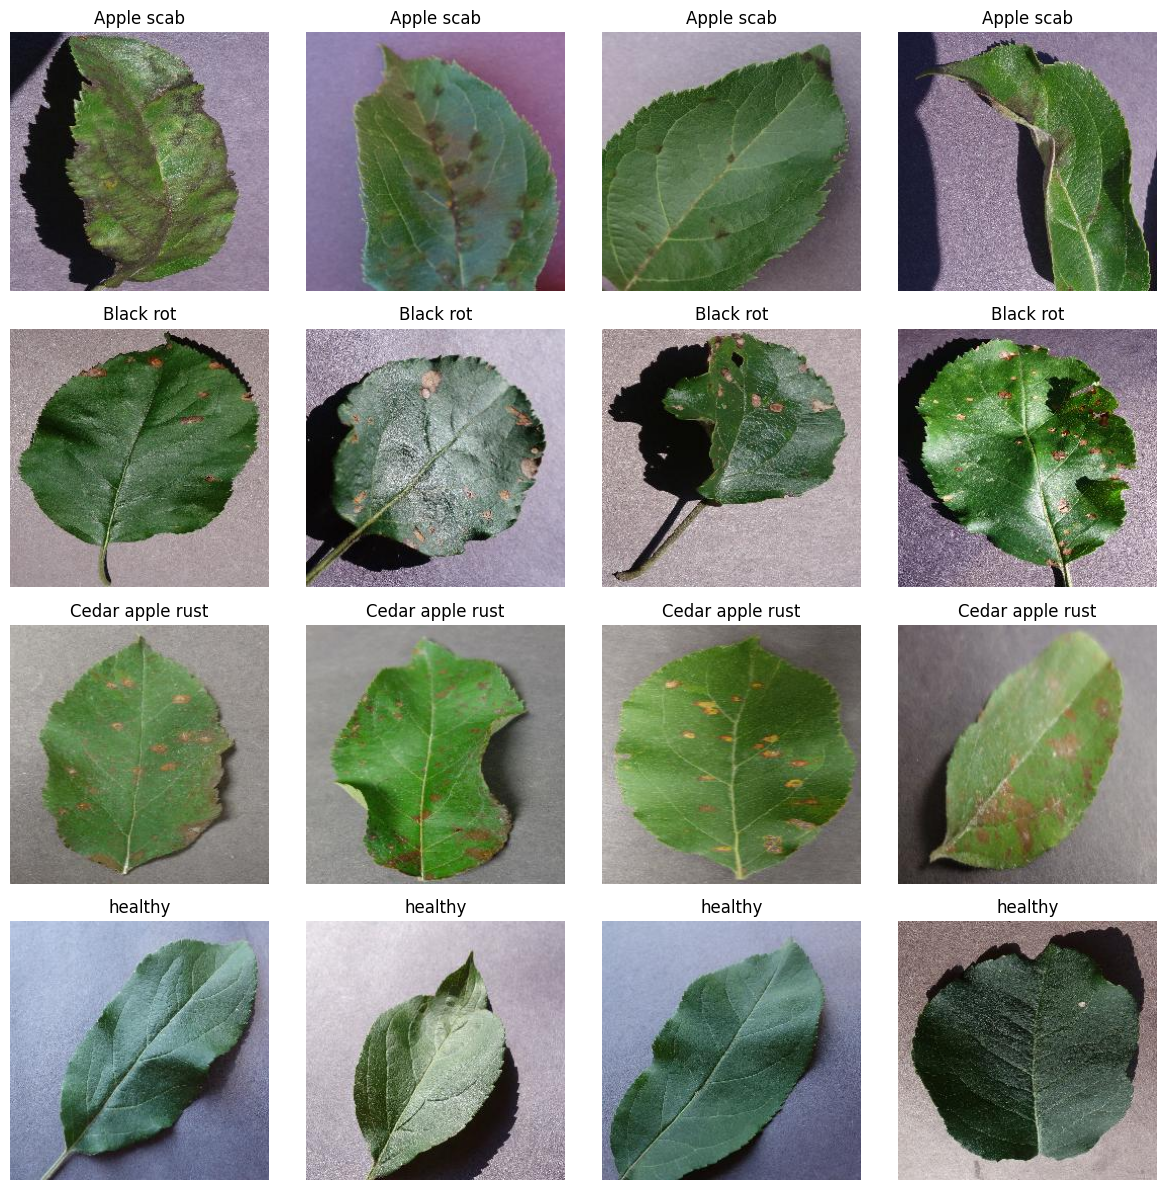

In [6]:
import matplotlib.pyplot as plt

SEED = 42

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, class_name in enumerate(APPLE_CLASSES):
    examples = (
        apple_df[apple_df["class_name"] == class_name]
        .sample(n=4, random_state=SEED)
    )

    for column, image_path in enumerate(examples["path"]):
        with Image.open(image_path) as image:
            axes[row, column].imshow(image.convert("RGB"))

        axes[row, column].set_title(
            class_name.replace("Apple___", "").replace("_", " ")
        )
        axes[row, column].axis("off")

plt.tight_layout()
plt.show()

In [7]:
import numpy as np

with Image.open(apple_df.iloc[0]["path"]) as image:
    image = image.convert("RGB")
    pixels = np.array(image)

print("Image shape:", pixels.shape)
print("Pixel data type:", pixels.dtype)
print("Pixel range:", pixels.min(), "to", pixels.max())
print("First pixel [R, G, B]:", pixels[0, 0])

Image shape: (256, 256, 3)
Pixel data type: uint8
Pixel range: 0 to 226
First pixel [R, G, B]: [167 163 196]


In [8]:
import hashlib

def image_hash(image_path):
    with Image.open(image_path) as image:
        image = image.convert("RGB")
        payload = str(image.size).encode() + image.tobytes()
        return hashlib.sha256(payload).hexdigest()

apple_df["image_hash"] = apple_df["path"].apply(image_hash)

# Identical pixels should not have different labels.
label_conflicts = (
    apple_df.groupby("image_hash")["label"]
    .nunique()
)

assert label_conflicts.max() == 1, (
    "Identical images have conflicting labels; inspect before continuing."
)

original_count = len(apple_df)

apple_df = (
    apple_df.drop_duplicates("image_hash")
    .reset_index(drop=True)
)

print("Exact duplicates removed:", original_count - len(apple_df))
print("Remaining images:", len(apple_df))

Exact duplicates removed: 7
Remaining images: 3164


In [9]:
from sklearn.model_selection import train_test_split

SEED = 42

train_df, remaining_df = train_test_split(
    apple_df,
    test_size=0.30,
    stratify=apple_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    remaining_df,
    test_size=0.50,
    stratify=remaining_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_counts = pd.DataFrame({
    "train": train_df["class_name"].value_counts(),
    "validation": val_df["class_name"].value_counts(),
    "test": test_df["class_name"].value_counts()
}).fillna(0).astype(int)

display(split_counts)

,train,validation,test
class_name,,,
Apple___healthy,1146,246,246
Apple___Apple_scab,441,94,95
Apple___Black_rot,435,93,93
Apple___Cedar_apple_rust,192,42,41


In [10]:
train_hashes = set(train_df["image_hash"])
val_hashes = set(val_df["image_hash"])
test_hashes = set(test_df["image_hash"])

assert train_hashes.isdisjoint(val_hashes)
assert train_hashes.isdisjoint(test_hashes)
assert val_hashes.isdisjoint(test_hashes)

print("No exact image overlap between splits.")

No exact image overlap between splits.


In [11]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

IMAGE_SIZE = 128
BATCH_SIZE = 32

baseline_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

In [12]:
class AppleLeafDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["path"]) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["label"])

        return image, label

In [13]:
train_dataset = AppleLeafDataset(train_df, baseline_transform)
val_dataset = AppleLeafDataset(val_df, baseline_transform)
test_dataset = AppleLeafDataset(test_df, baseline_transform)

generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

Image shape: torch.Size([32, 3, 128, 128])
Image type: torch.float32
Label shape: torch.Size([32])
Label type: torch.int64
Pixel range: 0.0 0.9843137264251709


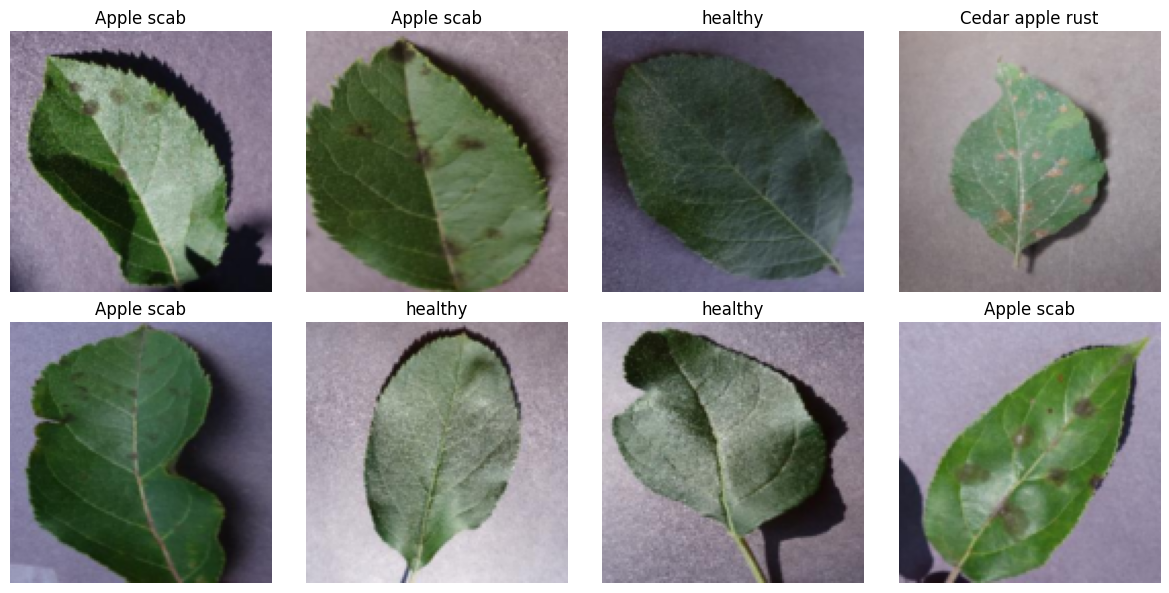

In [14]:
images,labels= next(iter(train_loader))
print("Image shape:", images.shape)
print("Image type:", images.dtype)
print("Label shape:", labels.shape)
print("Label type:", labels.dtype)
print("Pixel range:", images.min().item(), images.max().item())

assert images.shape[1:]==(3, IMAGE_SIZE, IMAGE_SIZE)
assert labels.dtype==torch.int64
assert labels.min().item() >=0
assert labels.min().item() <4

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for index,axis in enumerate(axes.flat):
   # Convert [C, H, W] back into [H, W, C] for display.
    axis.imshow(images[index].permute(1, 2, 0).numpy())

    class_name = index_to_class[labels[index].item()]
    axis.set_title(
        class_name.replace("Apple___", "").replace("_", " ")
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

In [15]:
import random
import numpy as np
import torch
import torch.nn as nn

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:" ,device)

Device: cpu


In [16]:
class AppleLeafCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            # [B, 3, 128, 128] → [B, 16, 64, 64]
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # → [B, 32, 32, 32]
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # → [B, 64, 16, 16]
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # → [B, 128, 8, 8]
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = AppleLeafCNN().to(device)

print(model)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"\nTrainable parameters: {parameter_count:,}")

AppleLeafCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)

Trainable parameters: 97,956


In [17]:
images, labels = next(iter(train_loader))

model.eval()

with torch.no_grad():
    x = images.to(device)

    print("Input:", tuple(x.shape))

    for layer in model.features:
        x = layer(x)
        print(
            f"{layer.__class__.__name__:20}",
            tuple(x.shape)
        )

    for layer in model.classifier:
        x = layer(x)
        print(
            f"{layer.__class__.__name__:20}",
            tuple(x.shape)
        )

Input: (32, 3, 128, 128)
Conv2d               (32, 16, 128, 128)
ReLU                 (32, 16, 128, 128)
MaxPool2d            (32, 16, 64, 64)
Conv2d               (32, 32, 64, 64)
ReLU                 (32, 32, 64, 64)
MaxPool2d            (32, 32, 32, 32)
Conv2d               (32, 64, 32, 32)
ReLU                 (32, 64, 32, 32)
MaxPool2d            (32, 64, 16, 16)
Conv2d               (32, 128, 16, 16)
ReLU                 (32, 128, 16, 16)
MaxPool2d            (32, 128, 8, 8)
AdaptiveAvgPool2d    (32, 128, 1, 1)
Flatten              (32, 128)
Dropout              (32, 128)
Linear               (32, 4)


In [18]:
model.eval()

with torch.no_grad():
    logits = model(images.to(device))
    probabilities = torch.softmax(logits, dim=1)

    confidence, predictions = probabilities.max(dim=1)

print("Output shape:", logits.shape)

print("\nFirst image:")
print("Raw scores:", logits[0].cpu())
print("Probabilities:", probabilities[0].cpu())
print("Probability sum:", probabilities[0].sum().item())

print(
    "Predicted class:",
    index_to_class[predictions[0].item()]
)

print(
    "Actual class:",
    index_to_class[labels[0].item()]
)

print("Confidence:", confidence[0].item())

Output shape: torch.Size([32, 4])

First image:
Raw scores: tensor([-0.0310,  0.0643,  0.0395, -0.0750])
Probabilities: tensor([0.2421, 0.2663, 0.2598, 0.2317])
Probability sum: 1.0
Predicted class: Apple___Black_rot
Actual class: Apple___Black_rot
Confidence: 0.26634618639945984


In [19]:
class_counts = (
    train_df["label"]
    .value_counts()
    .reindex(range(4))
    .to_numpy()
)

class_weights = len(train_df) / (4 * class_counts)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Class counts:", class_counts)
print("Class weights:", class_weights.cpu())

Class counts: [ 441  435  192 1146]
Class weights: tensor([1.2551, 1.2724, 2.8828, 0.4830])


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    loss_numerator = 0.0
    loss_denominator = 0.0

    all_labels = []
    all_predictions = []

    with torch.set_grad_enabled(is_training):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            if is_training:
                optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward() # how much did each parameter contribute to the error
                optimizer.step() #uses the gradients to update the CNN's weights

            # Weighted CrossEntropyLoss averages by target-weight sum.
            batch_weight = criterion.weight[labels].sum().item()

            loss_numerator += loss.item() * batch_weight
            loss_denominator += batch_weight

            predictions = logits.argmax(dim=1)

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

    return {
        "loss": loss_numerator / loss_denominator,
        "accuracy": accuracy_score(all_labels, all_predictions),
        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            labels=list(range(4)),
            average="macro",
            zero_division=0
        )
    }

In [ ]:
import copy
import time

EPOCHS = 15

history = []
best_val_f1 = -1.0
best_state = None
best_epoch = None

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_metrics = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_metrics = run_epoch(
        model,
        val_loader,
        criterion
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"]
    })

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch

        best_state = copy.deepcopy({
            name: value.cpu()
            for name, value in model.state_dict().items()
        })

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss: {train_metrics['loss']:.4f} | "
        f"Val loss: {val_metrics['loss']:.4f} | "
        f"Train acc: {train_metrics['accuracy']:.3f} | "
        f"Val acc: {val_metrics['accuracy']:.3f} | "
        f"Val F1: {val_metrics['macro_f1']:.3f} | "
        f"Time: {time.time() - start_time:.1f}s"
    )

model.load_state_dict(best_state) #model.state_dict stores all model's learned parameters

history_df = pd.DataFrame(history)

print(
    f"\nRestored epoch {best_epoch} "
    f"with validation macro F1 = {best_val_f1:.4f}"
)

Epoch 01/15 | Train loss: 1.3023 | Val loss: 1.0236 | Train acc: 0.336 | Val acc: 0.524 | Val F1: 0.510 | Time: 12.0s
Epoch 02/15 | Train loss: 1.0881 | Val loss: 0.9450 | Train acc: 0.444 | Val acc: 0.629 | Val F1: 0.567 | Time: 10.4s
Epoch 03/15 | Train loss: 0.9089 | Val loss: 0.8486 | Train acc: 0.546 | Val acc: 0.691 | Val F1: 0.663 | Time: 10.0s
Epoch 04/15 | Train loss: 0.8267 | Val loss: 0.6500 | Train acc: 0.616 | Val acc: 0.714 | Val F1: 0.717 | Time: 10.2s
Epoch 05/15 | Train loss: 0.6810 | Val loss: 0.5363 | Train acc: 0.693 | Val acc: 0.806 | Val F1: 0.796 | Time: 10.3s
Epoch 06/15 | Train loss: 0.6179 | Val loss: 0.4509 | Train acc: 0.741 | Val acc: 0.798 | Val F1: 0.800 | Time: 10.4s
Epoch 07/15 | Train loss: 0.5597 | Val loss: 0.3982 | Train acc: 0.764 | Val acc: 0.840 | Val F1: 0.812 | Time: 11.9s
Epoch 08/15 | Train loss: 0.5013 | Val loss: 0.5165 | Train acc: 0.802 | Val acc: 0.844 | Val F1: 0.798 | Time: 12.2s
Epoch 09/15 | Train loss: 0.4281 | Val loss: 0.3780 | Tr

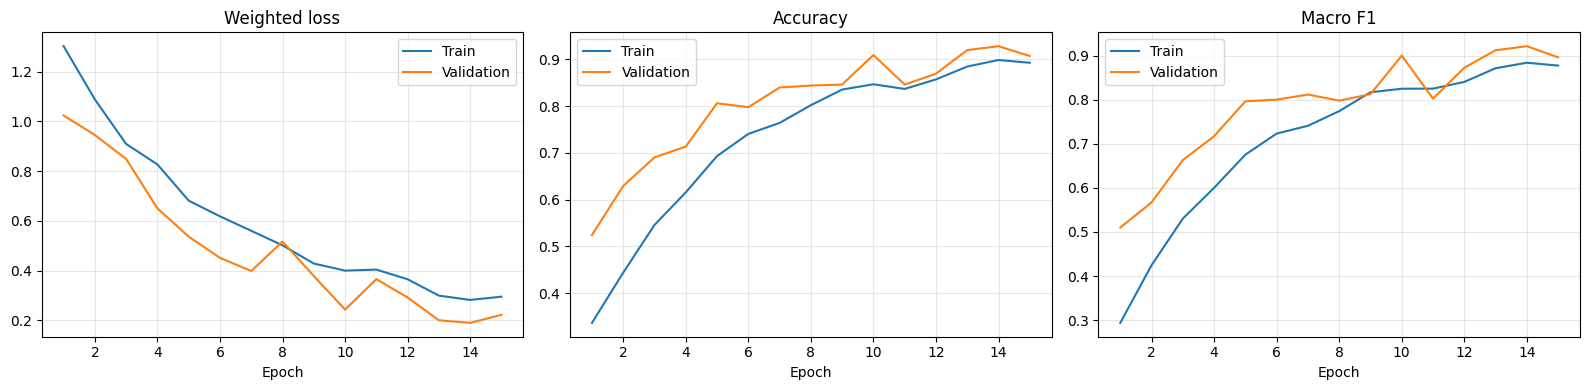

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plots = [
    ("loss", "Weighted loss"),
    ("accuracy", "Accuracy"),
    ("macro_f1", "Macro F1")
]

for axis, (metric, title) in zip(axes, plots):
    axis.plot(
        history_df["epoch"],
        history_df[f"train_{metric}"],
        label="Train"
    )

    axis.plot(
        history_df["epoch"],
        history_df[f"val_{metric}"],
        label="Validation"
    )

    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.legend()
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

model.eval()

test_labels = []
test_predictions = []
test_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)
        predictions = logits.argmax(dim=1)

        test_labels.extend(labels.tolist())
        test_predictions.extend(predictions.cpu().tolist())
        test_probabilities.extend(probabilities.cpu().tolist())

test_labels = np.array(test_labels)
test_predictions = np.array(test_predictions)
test_probabilities = np.array(test_probabilities)

class_names = [
    index_to_class[index]
    .replace("Apple___", "")
    .replace("_", " ")
    for index in range(4)
]

print(
    "Test accuracy:",
    f"{accuracy_score(test_labels, test_predictions):.4f}"
)

print(
    "Test macro F1:",
    f"{f1_score(test_labels, test_predictions, average='macro'):.4f}"
)

print("\nClassification report:")

print(classification_report(
    test_labels,
    test_predictions,
    labels=list(range(4)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

Test accuracy: 0.9284
Test macro F1: 0.9212

Classification report:
                  precision    recall  f1-score   support

      Apple scab     0.8804    0.8526    0.8663        95
       Black rot     0.8932    0.9892    0.9388        93
Cedar apple rust     0.8723    1.0000    0.9318        41
         healthy     0.9742    0.9228    0.9478       246

        accuracy                         0.9284       475
       macro avg     0.9051    0.9412    0.9212       475
    weighted avg     0.9308    0.9284    0.9284       475



In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(
    test_labels,
    test_predictions,
    labels=list(range(4))
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Baseline CNN — Test Confusion Matrix")
plt.tight_layout()
plt.show()

NameError: name 'confusion_matrix' is not defined

In [ ]:
baseline_model = model

checkpoint = {
    "model_state_dict": {
        name: tensor.detach().cpu().clone()
        for name, tensor in baseline_model.state_dict().items()
    },
    "class_to_index": class_to_index,
    "image_size": IMAGE_SIZE,
    "seed": SEED,
    "best_epoch": best_epoch,
    "test_accuracy": float(
        accuracy_score(test_labels, test_predictions)
    ),
    "test_macro_f1": float(
        f1_score(test_labels, test_predictions, average="macro")
    )
}

torch.save(checkpoint, "apple_baseline_checkpoint.pt")

from google.colab import files
files.download("apple_baseline_checkpoint.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
segmented_candidates = [
    folder
    for folder in dataset_path.rglob("*")
    if (
        folder.is_dir()
        and folder.name.lower() == "segmented"
        and all(
            (folder / class_name).is_dir()
            for class_name in APPLE_CLASSES
        )
    )
]

print("Segmented folder candidates:")
for folder in segmented_candidates:
    print(folder)

Segmented folder candidates:
/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented


In [ ]:
segmented_root = segmented_candidates[0]

segmented_lookup = {}

for class_name in APPLE_CLASSES:
    folder = segmented_root / class_name

    for path in folder.rglob("*"):
        if (
            path.is_file()
            and path.suffix.lower() in IMAGE_EXTENSIONS
        ):
            key = (class_name, path.stem)

            assert key not in segmented_lookup, (
                f"Duplicate segmented image key: {key}"
            )

            segmented_lookup[key] = str(path)


def find_segmented_path(row):
    key = (
        row["class_name"],
        Path(row["path"]).stem
    )
    return segmented_lookup.get(key)


val_mask_df = val_df.copy()

val_mask_df["segmented_path"] = val_mask_df.apply(
    find_segmented_path,
    axis=1
)

print("Validation images:", len(val_mask_df))
print("Matched:", val_mask_df["segmented_path"].notna().sum())
print("Unmatched:", val_mask_df["segmented_path"].isna().sum())

assert val_mask_df["segmented_path"].notna().all(), (
    "Some filenames did not match. Inspect them before continuing."
)

In [ ]:
def load_image_and_mask(original_path, segmented_path):
    with Image.open(original_path) as image:
        original = np.array(image.convert("RGB"))

    with Image.open(segmented_path) as image:
        segmented = np.array(image.convert("RGB"))

    assert original.shape == segmented.shape, (
        "Original and segmented images have different dimensions."
    )

    # True means foreground; False means background.
    # A small threshold tolerates near-black compression artifacts.
    mask = segmented.max(axis=2) > 10

    return original, segmented, mask

In [ ]:
def replace_background(original, mask, colour):
    background = np.empty_like(original)
    background[:] = colour

    return np.where(
        mask[..., None],
        original,
        background
    )

In [ ]:
audit_examples = pd.concat([
    val_mask_df[
        val_mask_df["class_name"] == class_name
    ].sample(n=2, random_state=SEED)
    for class_name in APPLE_CLASSES
]).reset_index(drop=True)

fig, axes = plt.subplots(
    len(audit_examples),
    5,
    figsize=(15, 3 * len(audit_examples))
)

column_titles = [
    "Original",
    "Dataset segmented",
    "Extracted mask",
    "White background",
    "Blue background"
]

for row_index, row in audit_examples.iterrows():
    original, segmented, mask = load_image_and_mask(
        row["path"],
        row["segmented_path"]
    )

    white_image = replace_background(
        original, mask, (255, 255, 255)
    )

    blue_image = replace_background(
        original, mask, (60, 120, 200)
    )

    panels = [
        original,
        segmented,
        mask,
        white_image,
        blue_image
    ]

    for column, panel in enumerate(panels):
        axis = axes[row_index, column]

        if column == 2:
            axis.imshow(panel, cmap="gray", vmin=0, vmax=1)
        else:
            axis.imshow(panel)

        axis.axis("off")

        if row_index == 0:
            axis.set_title(column_titles[column])

    axes[row_index, 0].set_title(
        row["class_name"]
        .replace("Apple___", "")
        .replace("_", " ")
    )

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader

BACKGROUND_COLOURS = {
    "original": None,
    "white": (255, 255, 255),
    "blue": (60, 120, 200),
    "black": (0, 0, 0),
}

class BackgroundTestDataset(Dataset):
    def __init__(self, dataframe, background_name, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.background_name = background_name
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["path"]) as image:
            original_image = image.convert("RGB")

        if self.background_name == "original":
            final_image = original_image
        else:
            original, _, mask = load_image_and_mask(
                row["path"],
                row["segmented_path"]
            )

            changed = replace_background(
                original,
                mask,
                BACKGROUND_COLOURS[self.background_name]
            )

            final_image = Image.fromarray(changed)

        image_tensor = self.transform(final_image)
        label = int(row["label"])

        return image_tensor, label

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

@torch.no_grad()
def predict_dataset(model, dataset):
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    model.eval()

    labels = []
    predictions = []
    confidences = []

    for images, batch_labels in loader:
        logits = model(images.to(device))
        probabilities = torch.softmax(logits, dim=1)

        batch_confidences, batch_predictions = (
            probabilities.max(dim=1)
        )

        labels.extend(batch_labels.numpy())
        predictions.extend(
            batch_predictions.cpu().numpy()
        )
        confidences.extend(
            batch_confidences.cpu().numpy()
        )

    return {
        "labels": np.array(labels),
        "predictions": np.array(predictions),
        "confidences": np.array(confidences)
    }

In [ ]:
baseline_results = {}

for background_name in BACKGROUND_COLOURS:
    dataset = BackgroundTestDataset(
        dataframe=val_mask_df,
        background_name=background_name,
        transform=baseline_transform
    )

    baseline_results[background_name] = predict_dataset(
        baseline_model,
        dataset
    )

original_labels = baseline_results["original"]["labels"]
original_predictions = baseline_results["original"]["predictions"]

rows = []

for background_name, result in baseline_results.items():
    assert np.array_equal(original_labels, result["labels"])

    rows.append({
        "background": background_name,
        "accuracy": accuracy_score(
            result["labels"],
            result["predictions"]
        ),
        "macro_f1": f1_score(
            result["labels"],
            result["predictions"],
            labels=list(range(4)),
            average="macro",
            zero_division=0
        ),
        "prediction_change_rate": np.mean(
            result["predictions"] != original_predictions
        ),
        "mean_confidence": np.mean(
            result["confidences"]
        )
    })

background_results_df = pd.DataFrame(rows)

display(
    background_results_df.round(4)
)   

In [ ]:
class_rows = []

for background_name, result in baseline_results.items():
    for class_index in range(4):
        class_mask = original_labels == class_index

        class_rows.append({
            "background": background_name,
            "class": index_to_class[class_index],
            "samples": class_mask.sum(),
            "recall": np.mean(
                result["predictions"][class_mask]
                == original_labels[class_mask]
            ),
            "prediction_change_rate": np.mean(
                result["predictions"][class_mask]
                != original_predictions[class_mask]
            )
        })

class_background_df = pd.DataFrame(class_rows)

display(
    class_background_df.round(4)
)